# **Exploratory Data Analysis**

In [5]:
# import các thư viện cần thiết
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

# Đọc dữ liệu từ file CSV
df_train = pd.read_csv("../data/raw/train.csv")
df_test = pd.read_csv("../data/raw/test.csv")


In [6]:
# Hiển thị thông tin cơ bản về dữ liệu
print(df_train.info())

print("Hiển thị 5 dòng đầu tiên của tập dữ liệu training:")
df_train.head()

<class 'pandas.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  str    
 2   Gender                                 140700 non-null  str    
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  str    
 5   Working Professional or Student        140700 non-null  str    
 6   Profession                             104070 non-null  str    
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     27897 non-null   float64
 11

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [7]:
print("Hiển thị 5 dòng đầu tiên của tập dữ liệu test:")
df_test.head()

Hiển thị 5 dòng đầu tiên của tập dữ liệu test:


,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,140700,Shivam,Male,53.0,Visakhapatnam,Working Professional,Judge,NaN,2.0,NaN,NaN,5.0,Less than 5 hours,Moderate,LLB,No,9.0,3.0,Yes
1,140701,Sanya,Female,58.0,Kolkata,Working Professional,Educational Consultant,NaN,2.0,NaN,NaN,4.0,Less than 5 hours,Moderate,B.Ed,No,6.0,4.0,No
2,140702,Yash,Male,53.0,Jaipur,Working Professional,Teacher,NaN,4.0,NaN,NaN,1.0,7-8 hours,Moderate,B.Arch,Yes,12.0,4.0,No
3,140703,Nalini,Female,23.0,Rajkot,Student,NaN,5.0,NaN,6.84,1.0,NaN,More than 8 hours,Moderate,BSc,Yes,10.0,4.0,No
4,140704,Shaurya,Male,47.0,Kalyan,Working Professional,Teacher,NaN,5.0,NaN,NaN,5.0,7-8 hours,Moderate,BCA,Yes,3.0,4.0,No


## **Data overview**

**Basic Information**

In [8]:
print(f"Number of rows in training set: {df_train.shape[0]}")
print(f"Number of columns in training set: {df_train.shape[1]}")
print(f"Overall size of training set: {df_train.size}")

print(f"Number of rows in test set: {df_test.shape[0]}")
print(f"Number of columns in test set: {df_test.shape[1]}")
print(f"Overall size of test set: {df_test.size}")

Number of rows in training set: 140700
Number of columns in training set: 20
Overall size of training set: 2814000
Number of rows in test set: 93800
Number of columns in test set: 19
Overall size of test set: 1782200


**Data Integrity**

In [9]:
print("Number of duplicate rows in training set:", df_train.duplicated().sum())
print("Number of entirely empty rows in training set:", df_train.isnull().all(axis=1).sum())

Number of duplicate rows in training set: 0
Number of entirely empty rows in training set: 0


**Column Inventory**

Ý nghĩa từng biến:

| STT | Tên biến | Ý nghĩa | Kiểu dữ liệu |
|-----|----------|---------|--------| 
| 1 | id | Mã định danh duy nhất của mỗi khách hàng | Categorical |
| 2 | Name | Tên | Categorical |
| 3 | Gender | Giới tính | Binary Categorical (Male, Female) |
| 4 | Age | Tuổi | Numeric |
| 5 | City | Thành phố sinh sống | Categorical |
| 6 | Working Professional or Student | Là Người đi làm hay Sinh viên | Binary Categorical (Working Professional, Student) |
| 7 | Profession | Nghề nghiệp | Categorical |
| 8 | Academic Pressure | Mức độ Áp lực học tập | Ordinal Numeric (0-5) |
| 9 | Work Pressure | Mức độ Áp lực công việc | Ordinal Numeric (0-5) |
| 10 | CGPA | Điểm trung bình học tập | Numeric |
| 11 | Study Satisfaction | Mức độ hài lòng về học tập | Ordinal Numeric (0-5) |
| 12 | Job Satisfaction | Mức độ hài lòng về công việc | Ordinal Numeric (0-5) |
| 13 | Sleep Duration | Thời gian ngủ | Categorical |
| 14 | Dietary Habits	 | Chế độ ăn uống | Categorical |
| 15 | Degree | Bằng cấp | Categorical |
| 16 | Have you ever had suicidal thoughts ? | Có ý định tự tử chưa | Binary Categorical (Yes, No) |
| 17 | Work/Study Hours | Thời gian học tập/ làm việc | Numeric |
| 18 | Financial Stress | Mức độ áp lực tài chính | Ordinal Numeric (0-5) |
| 19 | Family History of Mental Illness | Gia đình có tiền sử bệnh tâm thần hay không | Binary Categorical (Yes, No) |
| 20 | **Depression (target)** | Tình trạng trầm cảm | Binary Numeric (1: Có, 0: Không) |

**Nhận xét:**
- Những cột có khả năng tương quan cao với biến mục tiêu: `Have you ever had suicidal thoughts ?`, `Work Pressure`, `Academic Pressure`
- Những cột nên drop sau này do không có giá trị cho mô hình dự đoán: `id` (do chỉ mang ý nghĩa định danh)

## **Missing Data Analysis**

In [10]:
# Thống kê dữ liệu thiếu theo mỗi cột và phần trăm dữ liệu thiếu
missing = df_train.isnull().sum()
missing_percent = (missing / len(df_train) * 100).round(2)

print(f"Trên tổng số {len(df_train)} dòng trong tập training")
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage (%)': missing_percent,
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Percentage (%)', ascending=False)

if missing_df.empty:
    print('Không có giá trị thiếu trong tập training.')
else:
    display(missing_df)

Trên tổng số 140700 dòng trong tập training


,Missing Count,Missing Percentage (%)
Academic Pressure,112803,80.17
CGPA,112802,80.17
Study Satisfaction,112803,80.17
Profession,36630,26.03
Work Pressure,27918,19.84
Job Satisfaction,27910,19.84
Dietary Habits,4,0.00
Degree,2,0.00
Financial Stress,4,0.00


**Nhận xét:**
- Ta nhận thấy có pattern giữa các cặp dữ liệu sẽ có 1 cột chứa giá trị và cột còn lại sẽ missing. Đó là các cặp `Academic Pressure <--> Work Pressure`, `Study Satisfaction <--> Job Satisfaction`. Điều này vẫn đảm bảo độ phủ của dữ liệu
- Với cột `Profession` có pattern thiếu do người đó là Student.
- Các cột thật sự missing dữ liệu và cần cách xử lý thích hợp ở phần Preprocessing là: `Degree`, `Financial Stress`, `Dietary Habits`. 

--> Cách xử lý dự kiến có thể là điền Unknow cho cột categorical và điền trung vị cho cột numeric để không làm ảnh hưởng phân phối.

In [11]:
# Kiểm tra các Student có các giá trị thiếu ở các cột chứa Academic
missing_academic_cols = ['Academic Pressure', 'CGPA', 'Study Satisfaction']
df_Student = df_train[df_train['Working Professional or Student'] == 'Student']
missing_academic = df_Student[missing_academic_cols].isnull().sum()
print("Số lượng giá trị thiếu thực sự với các cột Academic với role là Student:")
print(missing_academic)


Số lượng giá trị thiếu thực sự với các cột Academic với role là Student:
Academic Pressure      9
CGPA                   9
Study Satisfaction    10
dtype: int64


In [12]:
# Kiểm tra Working Professional nhưng vẫn có giá trị thiếu ở các cột Job
missing_job_cols = ['Job Satisfaction', 'Work Pressure', 'Profession']
df_Working_Professional = df_train[df_train['Working Professional or Student'] == 'Working Professional']
missing_job = df_Working_Professional[missing_job_cols].isnull().sum()
print("Số lượng giá trị thiếu thực sự với các cột Job với role là Working Professional:")
print(missing_job)


Số lượng giá trị thiếu thực sự với các cột Job với role là Working Professional:
Job Satisfaction      17
Work Pressure         20
Profession          8763
dtype: int64


**Nhận xét:** Với các trường hợp đúng role nhưng các cột liên quan đến role lại missing cần có cách xử lý riêng. Phần này sẽ được giải thích kĩ hơn ở phần preprocessing.


## **Numerical Columns Analysis**

**Range & Outliers**

In [13]:
# Thống kê mô tả cho các cột số
df_train.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,140700.000000,140700.000000,27897.000000,112782.000000,27898.000000,27897.000000,112790.000000,140700.000000,140696.000000,140700.000000
mean,70349.500000,40.388621,3.142273,2.998998,7.658636,2.944940,2.974404,6.252679,2.988983,0.181713
std,40616.735775,12.384099,1.380457,1.405771,1.464466,1.360197,1.416078,3.853615,1.413633,0.385609
min,0.000000,18.000000,1.000000,1.000000,5.030000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,35174.750000,29.000000,2.000000,2.000000,6.290000,2.000000,2.000000,3.000000,2.000000,0.000000
50%,70349.500000,42.000000,3.000000,3.000000,7.770000,3.000000,3.000000,6.000000,3.000000,0.000000
75%,105524.250000,51.000000,4.000000,4.000000,8.920000,4.000000,4.000000,10.000000,4.000000,0.000000
max,140699.000000,60.000000,5.000000,5.000000,10.000000,5.000000,5.000000,12.000000,5.000000,1.000000


In [14]:
# 1. Range Analysis: Min & Max Values
# Tính toán min/max cho các cột số
numeric_cols = df_train.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['Depression', 'id'], errors='ignore')  # Loại bỏ cột target và id nếu có
range_df = df_train[numeric_cols].agg(['min', 'max']).T

# 2. Outlier Detection using IQR Method
# Hàm phát hiện outlier
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound, outliers[column].unique()

# Phân tích outliers cho từng cột số và lưu vào DataFrame
outlier_results = []
for col in numeric_cols:
    count, lower, upper, unique_outliers = detect_outliers_iqr(df_train, col)
    bounds = f"{lower:.1f} to {upper:.1f}"
    # Chỉ hiển thị vài giá trị outlier đại diện
    if len(unique_outliers) < 10:
        outlier_str = str(sorted(unique_outliers))
    else:
        outlier_str = str(sorted(unique_outliers)[:5]) + "..."
    outlier_results.append({
        'Column': col,
        'Count': count,
        'Bounds (Min-Max)': bounds,
        'Extreme Values Found': outlier_str
    })
outlier_df = pd.DataFrame(outlier_results)
# Gộp hai bảng range_df (min/max) và outlier_df thành một bảng tổng hợp
summary_df = range_df.copy()
summary_df = summary_df.merge(outlier_df.set_index('Column'), left_index=True, right_index=True, how='left')
# Đổi tên cột cho rõ ràng
summary_df = summary_df.rename(columns={
    'min': 'Min',
    'max': 'Max',
    'Count': 'Outlier Count',
    'Bounds (Min-Max)': 'Outlier Bounds',
    'Extreme Values Found': 'Outlier Values',
    'Reasonable?': 'Reasonable? (Manual Check)'
})
print("--- BẢNG TỔNG HỢP MIN/MAX & OUTLIER ---")
display(summary_df.sort_values(by='Outlier Count', ascending=False))

--- BẢNG TỔNG HỢP MIN/MAX & OUTLIER ---


,Min,Max,Outlier Count,Outlier Bounds,Outlier Values
Age,18.00,60.0,0,-4.0 to 84.0,[]
Academic Pressure,1.00,5.0,0,-1.0 to 7.0,[]
Work Pressure,1.00,5.0,0,-1.0 to 7.0,[]
CGPA,5.03,10.0,0,2.3 to 12.9,[]
Study Satisfaction,1.00,5.0,0,-1.0 to 7.0,[]
Job Satisfaction,1.00,5.0,0,-1.0 to 7.0,[]
Work/Study Hours,0.00,12.0,0,-7.5 to 20.5,[]
Financial Stress,1.00,5.0,0,-1.0 to 7.0,[]


**Distribution & Central Tendency**

In [15]:
y = df_train["Depression"]
print(f"Number of unique values in target variable: {y.nunique()}\nValues: {np.sort(y.unique())}")

Number of unique values in target variable: 2
Values: [0 1]


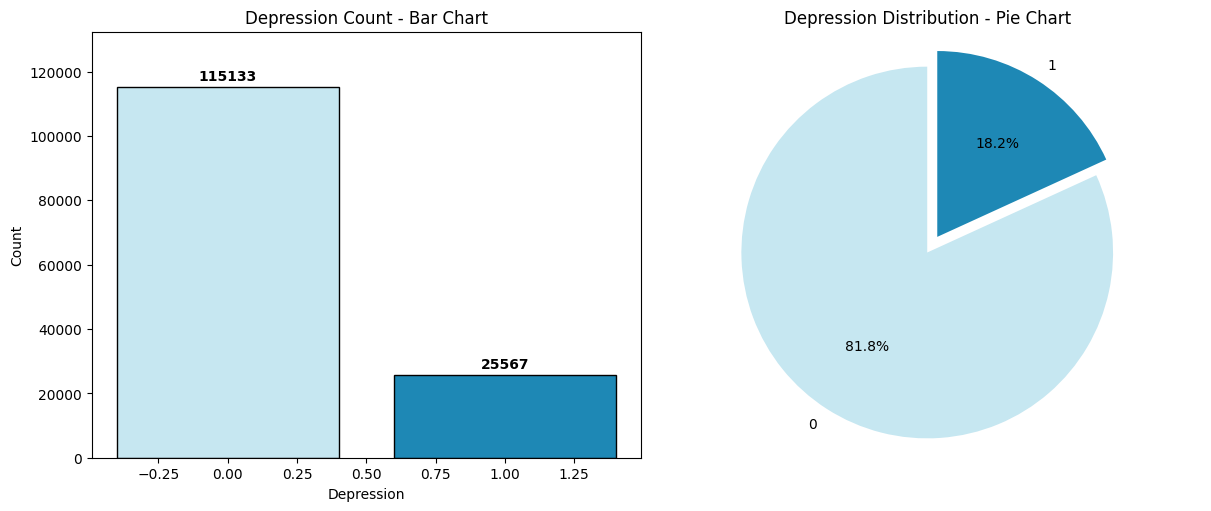

In [16]:
# Phân phối của biến mục tiêu
palette = ['#C6E7F1', '#1e88b5']

target_counts = df_train['Depression'].value_counts().sort_index()
target_labels = target_counts.index.tolist()
target_values = target_counts.values

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Bar chart
bars = axes[0].bar(target_labels, target_values, color=palette[:len(target_values)], edgecolor='black')
axes[0].set_title('Depression Count - Bar Chart')
axes[0].set_xlabel('Depression')
axes[0].set_ylabel('Count')
axes[0].bar_label(bars, padding=3, fmt='%d', fontweight='bold')
axes[0].set_ylim(0, target_values.max() * 1.15)

# Pie chart
axes[1].pie(
    target_values,
    labels=target_labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=palette[:len(target_values)],
    explode=[0.05] * len(target_values)
)
axes[1].set_title('Depression Distribution - Pie Chart')
axes[1].axis('equal')

plt.show()

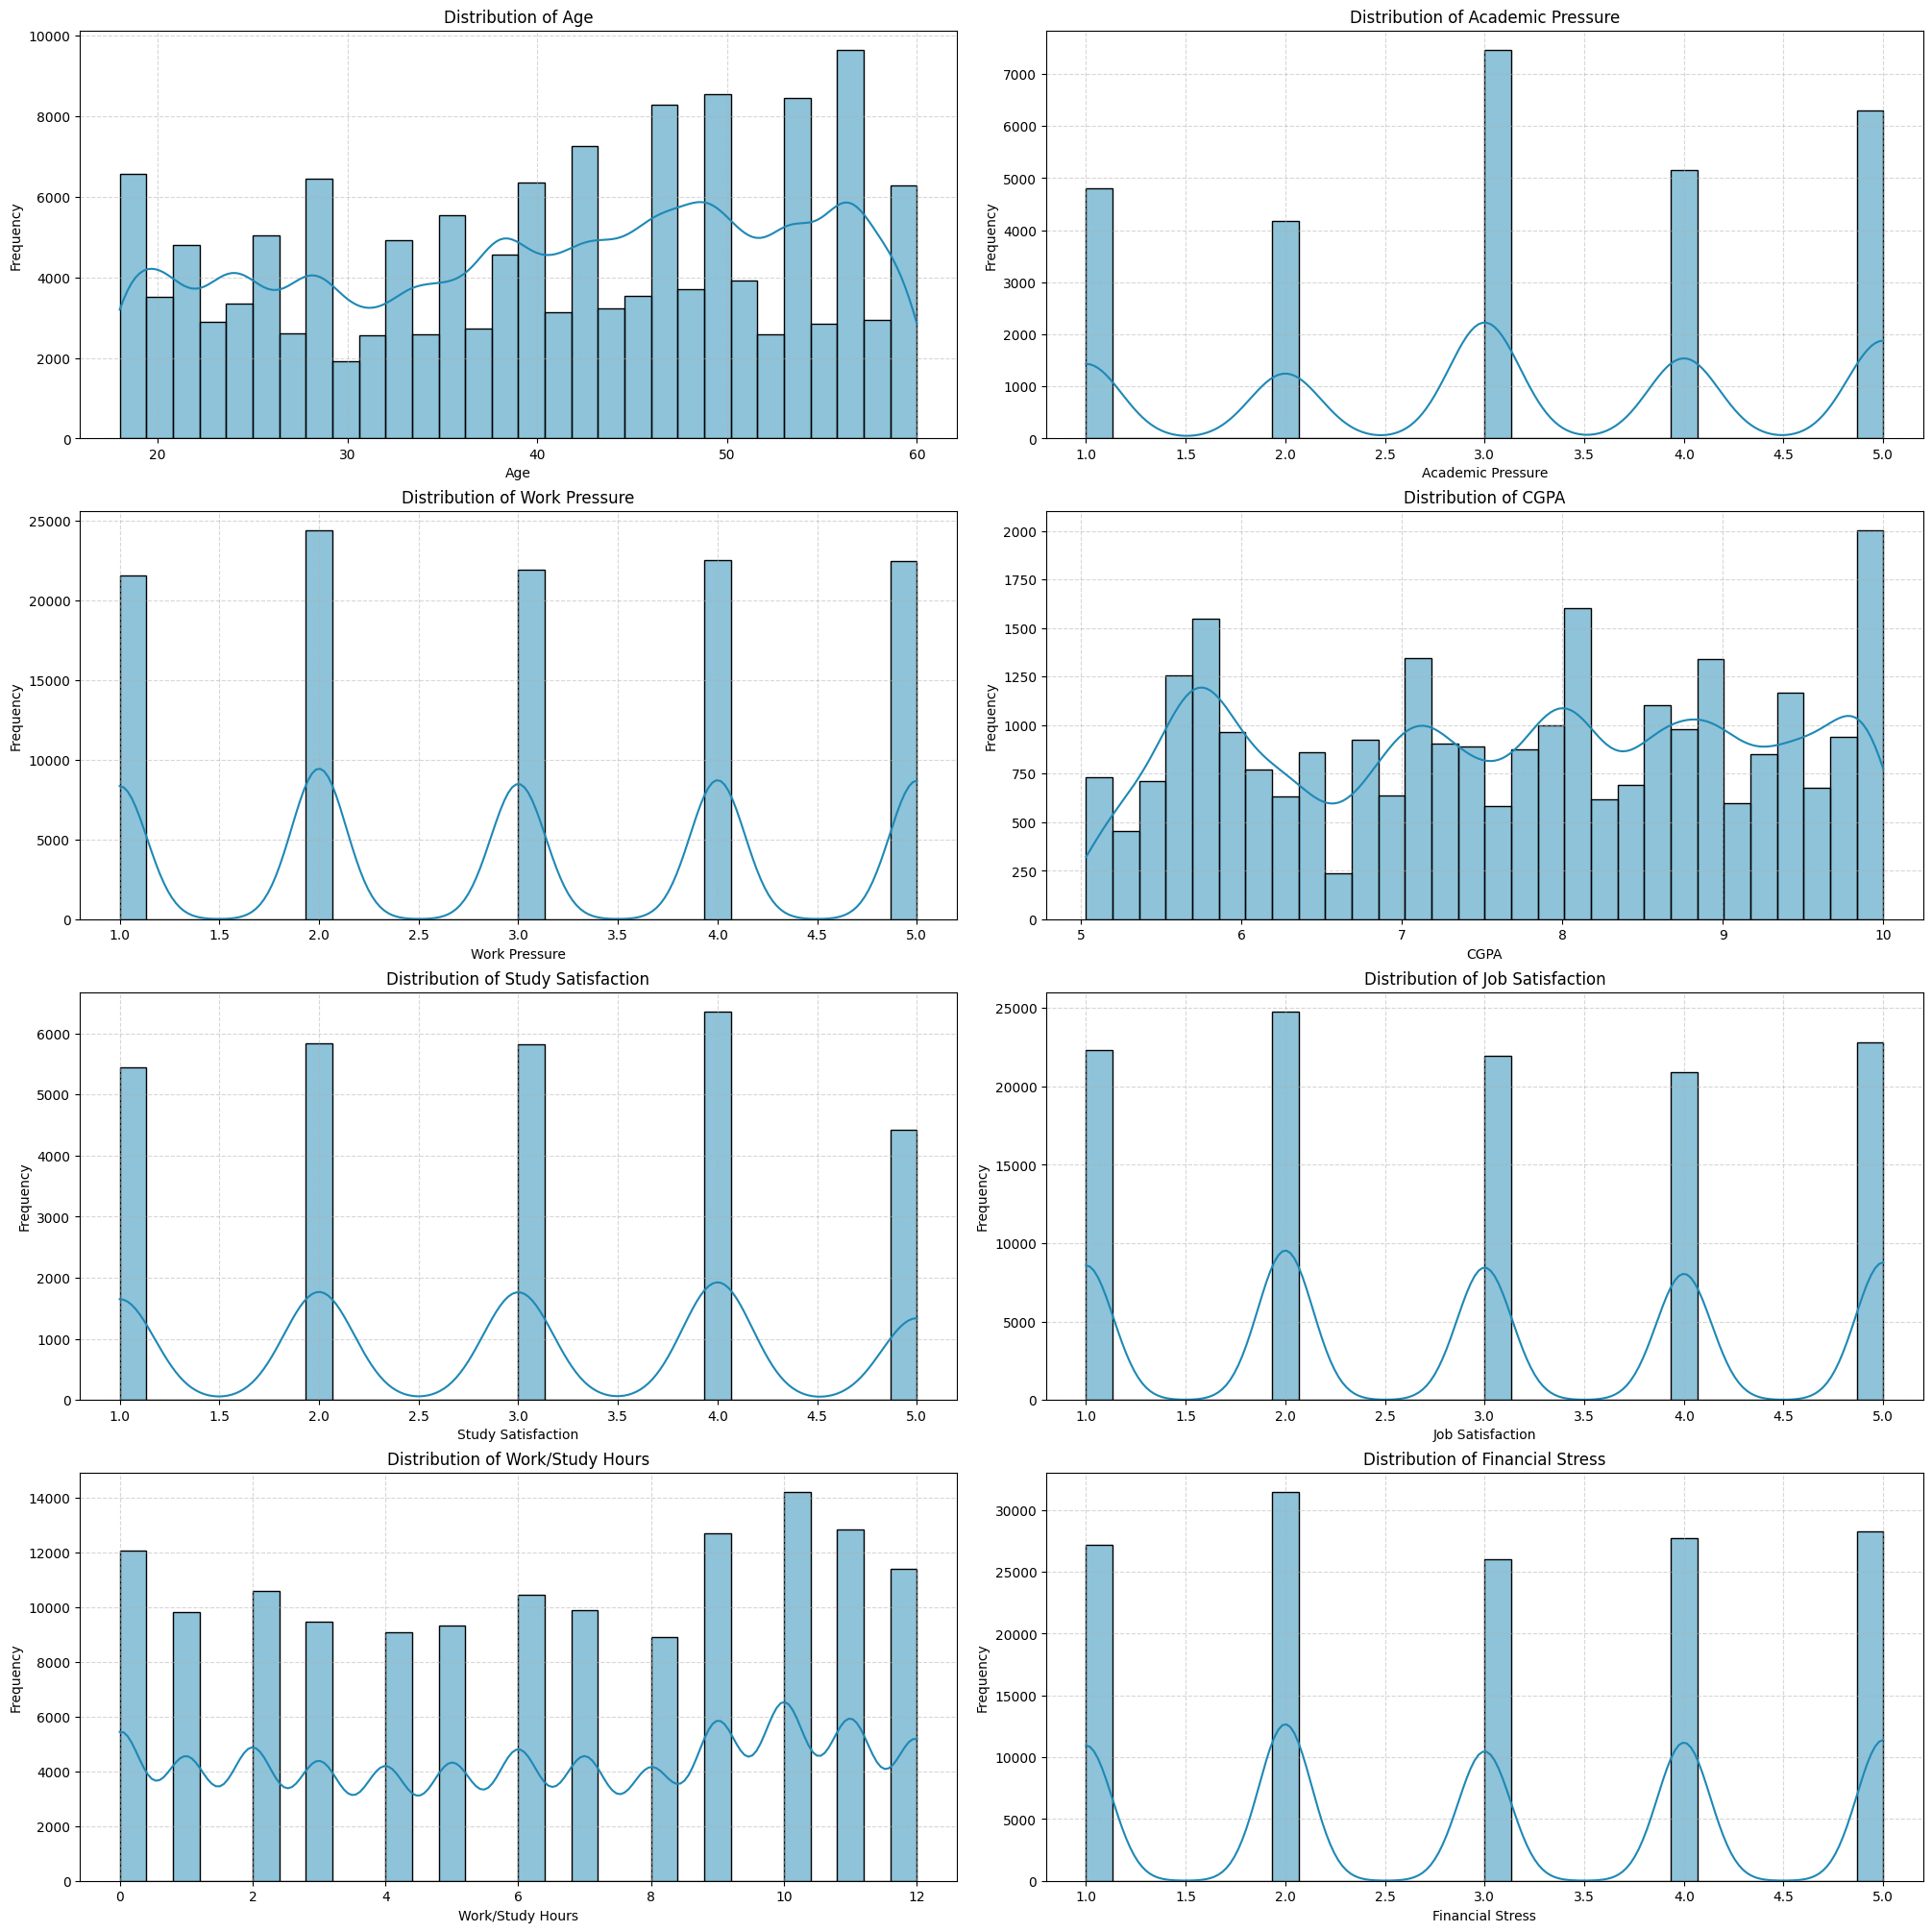

In [17]:
# Phân phối của 8 cột số còn lại
numeric_cols = df_train.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['Depression', 'id'], errors='ignore')  # Loại bỏ cột target và id nếu có
num_cols = len(numeric_cols)
cols = 2
rows = math.ceil(num_cols / cols)
fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows), constrained_layout=True)
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df_train[col], bins=30, kde=True, ax=axes[i], color='#1e88b5')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, linestyle='--', alpha=0.5)
# Ẩn các subplot còn lại nếu có
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.show()


**Nhận xét:**

*Đối với biến mục tiêu `Depression`:* 

+ Bộ dữ liệu bị mất cân bằng khá lớn với giá trị *0* nhiều hơn hẳn so với giá trị *1*
+ Cần xử lý mất cân bằng dữ liệu trước khi train model.
+ Các cách xử lý mất cân bằng dự kiến: SMOTE, class weighting hoặc balanced sampling

*Đối với các biến numeric còn lại:*

+ Không ghi nhận thấy giá trị ngoại lai nào
+ Phân phối của tất cả các giá trị khá chuẩn, có thể không cần transform mà vẫn có kết quả tốt.

## **Categorical Columns Analysis**

In [18]:
# Lọc các cột categorical
cat_cols = df_train.select_dtypes(include=['object', 'string']).columns
cat_cols = cat_cols.drop('Name', errors='ignore')
print(f"Categorical colums: {cat_cols}")

Categorical colums: Index(['Gender', 'City', 'Working Professional or Student', 'Profession',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?',
       'Family History of Mental Illness'],
      dtype='str')


In [19]:
# Thống kê số lượng giá trị unique cho mỗi cột categorical và số lượng giá trị có count < 20
cat_summary = []
for col in cat_cols:
    unique_values = df_train[col].nunique()
    low_count_values = df_train[col].value_counts()[df_train[col].value_counts() < 20].count()
    cat_summary.append({
        'Column': col,
        'Unique Values': unique_values,
        'Values with Count < 20': low_count_values
    })
cat_summary_df = pd.DataFrame(cat_summary)
print("--- Categorical Columns Summary ---")
display(cat_summary_df)

--- Categorical Columns Summary ---


,Column,Unique Values,Values with Count < 20
0,Gender,2,0
1,City,98,68
2,Working Professional or Student,2,0
3,Profession,64,29
4,Sleep Duration,36,32
5,Dietary Habits,23,20
6,Degree,115,88
7,Have you ever had suicidal thoughts ?,2,0
8,Family History of Mental Illness,2,0


In [20]:
# Đổi các giá trị có count < 20 thành 'Other' để giảm số lượng category
for col in cat_cols:
    value_counts = df_train[col].value_counts()
    to_replace = value_counts[value_counts < 20].index
    df_train[col] = df_train[col].replace(to_replace, 'Other')



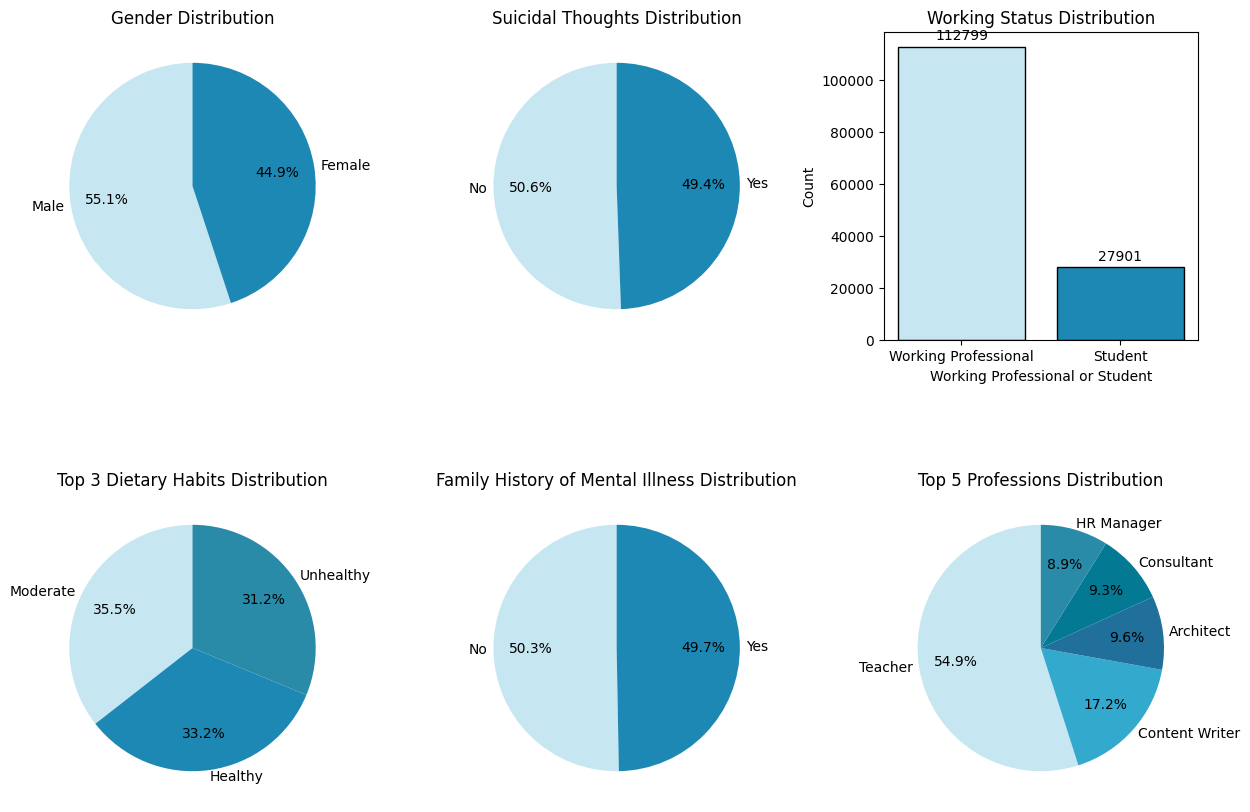

In [21]:
colors = ['#C6E7F1', '#1e88b5', '#298BA8', '#1f5880', '#1b4266']
palette = colors
# Remove 'Unknown' or null professions
train_clean = df_train[~df_train['Profession'].isin(['Unknown']) & df_train['Profession'].notnull()]
# Remove Dietary Habits with 'Unknown' or null values
train_clean = train_clean[~train_clean['Dietary Habits'].isin(['Unknown']) & train_clean['Dietary Habits'].notnull()]

# Top 5 professions after cleaning
top5_professions = train_clean['Profession'].value_counts().head(5)
# Top 3 dietary habits after cleaning
top3_dietary_habits = train_clean['Dietary Habits'].value_counts().head(3)

# Setup subplots
fig, axes = plt.subplots(2, 3, figsize=(15,10))
fig.subplots_adjust(hspace=0.5, wspace=0.35)

# Gender
gender_counts = df_train['Gender'].value_counts()
axes[0,0].pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    labeldistance=1.05,
    pctdistance=0.7
)
axes[0,0].set_title('Gender Distribution')

# Have you ever had suicidal thoughts ? Pie chart
suicidal_counts = df_train['Have you ever had suicidal thoughts ?'].value_counts()
axes[0,1].pie(
    suicidal_counts,
    labels=suicidal_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    labeldistance=1.05,
    pctdistance=0.7
)
axes[0,1].set_title('Suicidal Thoughts Distribution')


# Working Professional or Student 
working_status_counts = df_train['Working Professional or Student'].value_counts()
bars = axes[0,2].bar(
    working_status_counts.index,
    working_status_counts.values,
    color=palette[:len(working_status_counts)],
    edgecolor='black'
)
axes[0,2].set_title('Working Status Distribution')
axes[0,2].set_xlabel('Working Professional or Student')
axes[0,2].set_ylabel('Count')
axes[0,2].bar_label(bars, fmt='%d', padding=3)


# Dietary Habits
axes[1,0].pie(
    top3_dietary_habits,
    labels=top3_dietary_habits.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    labeldistance=1.05,
    pctdistance=0.7
)
axes[1,0].set_title('Top 3 Dietary Habits Distribution')

# Family History of Mental Illness Pie chart
family_history_counts = df_train['Family History of Mental Illness'].value_counts()
axes[1,1].pie(
    family_history_counts,
    labels=family_history_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    labeldistance=1.05,
    pctdistance=0.7
)
axes[1,1].set_title('Family History of Mental Illness Distribution')


# Top 5 Professions 
color = ['#C6E7F1', '#32A9CD', '#20709b', '#047994', '#298BA8', '#80d0f0', '#a0e0f5']

axes[1,2].pie(
    top5_professions,
    labels=top5_professions.index,
    autopct='%1.1f%%',
    colors=color,
    startangle=90,
    labeldistance=1.05,
    pctdistance=0.7
)
axes[1,2].set_title('Top 5 Professions Distribution')

plt.show()

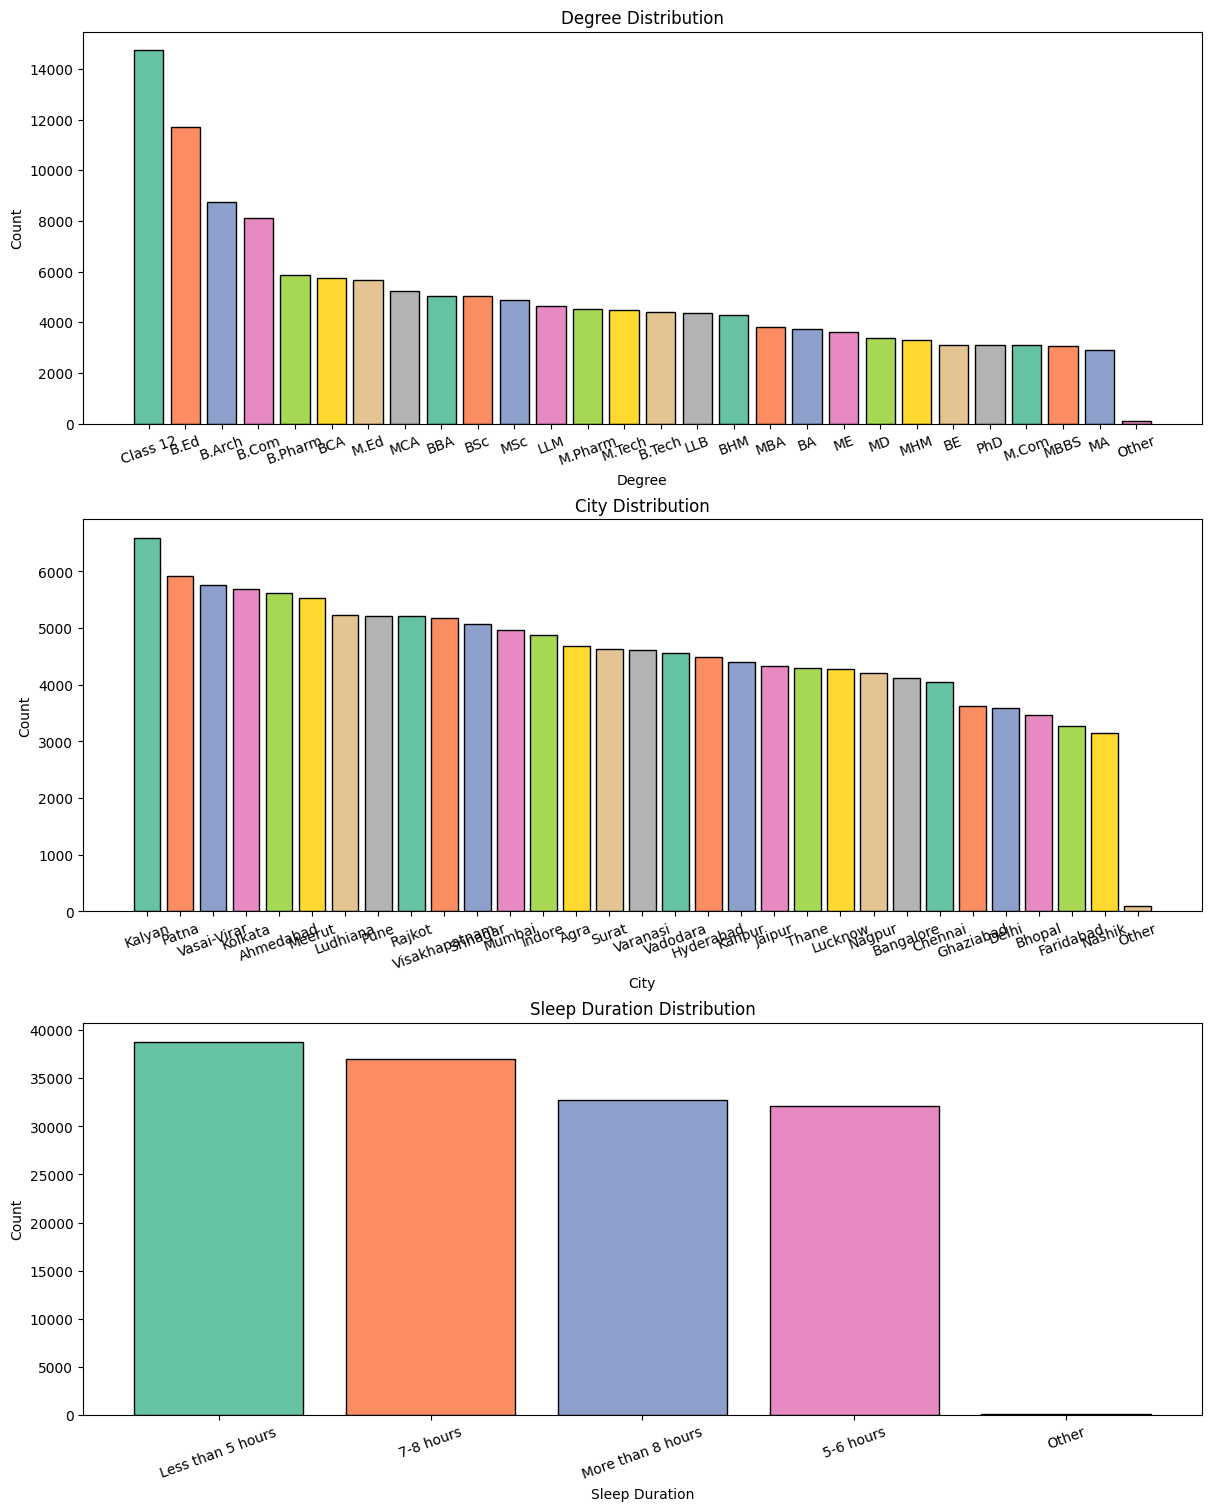

In [22]:
# Vẽ biểu đồ phân phối với các cột 'Degree', 'City', 'Sleep Duration'
fig, axes = plt.subplots(3, 1, figsize=(12, 15), constrained_layout=True)

# Degree
degree_counts = df_train['Degree'].value_counts()
axes[0].bar(degree_counts.index, degree_counts.values, color=sns.color_palette('Set2', len(degree_counts)), edgecolor='black')
axes[0].set_title('Degree Distribution')
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

# City
city_counts = df_train['City'].value_counts()
axes[1].bar(city_counts.index, city_counts.values, color=sns.color_palette('Set2', len(city_counts)), edgecolor='black')
axes[1].set_title('City Distribution')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)

# Sleep Duration
sleep_counts = df_train['Sleep Duration'].value_counts()
axes[2].bar(sleep_counts.index, sleep_counts.values, color=sns.color_palette('Set2', len(sleep_counts)), edgecolor='black')
axes[2].set_title('Sleep Duration Distribution')
axes[2].set_xlabel('Sleep Duration')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=20)
plt.show()


#### **Nhận xét:**

1. Số lượng giá trị duy nhất của mỗi đặc trưng rất nhiều, đa phần đều có giá trị đếm <20 --> Nên gộp nhóm các giá trị này thành 'Other' để tránh phân mảnh và transform quá nhiều
2. Phân phối của các đặc trưng:
- Các đặc trưng có phân phối khá đều: `Gender`, `Have you ever had suicidal thoughts ?`, `Dietary Habits`, `Family History`
- Đặc trưng `Working Status`: số lượng khảo sát là Working Profession nhiều gấp 4 lần so với vai trò là Student làm dữ liệu bị lệch khá rõ. --> Cần resampling ở bước sau để model có thể học tốt hơn.
- Đặc trưng `Professions`: số lượng là Teacher chiếm hơn 50% tỉ trọng, điều này có thể làm cho mô hình bị bias nếu không có cách tiền xử lý tốt.
- Đặc trưng `Degree`: bị lệch mạnh về một vài nhóm đầu như Class 12, B.Ed, B.Arch, B.Com sau đó giảm nhanh và ổn định dần ở những bằng cấp còn lại.
- Đặc trưng `City`: phân phối khá dàn trải, không tập trung tuyệt đối vào một nhóm.
- Đặc trưng `Sleep Duration`: phần lớn mẫu rơi vào Less than 5 hours và 7-8 hours. Nhóm 5-6 hours và More than 8 hours thấp hơn, còn Other gần như không đáng kể. --> Việc thay thế nhóm thiểu số thành Other chỉ mang mục đích EDA tốt hơn. Quá trình tiền xử lý sau này có thể xử lý dữ liệu bằng cách mapping lấy trung bình của khoảng thời gian thay vì gom nhóm.


## **Relationships & Correlations**

**Correlation Analysis**

Text(0.5, 1.0, 'Correlation Heatmap of Numeric Features')

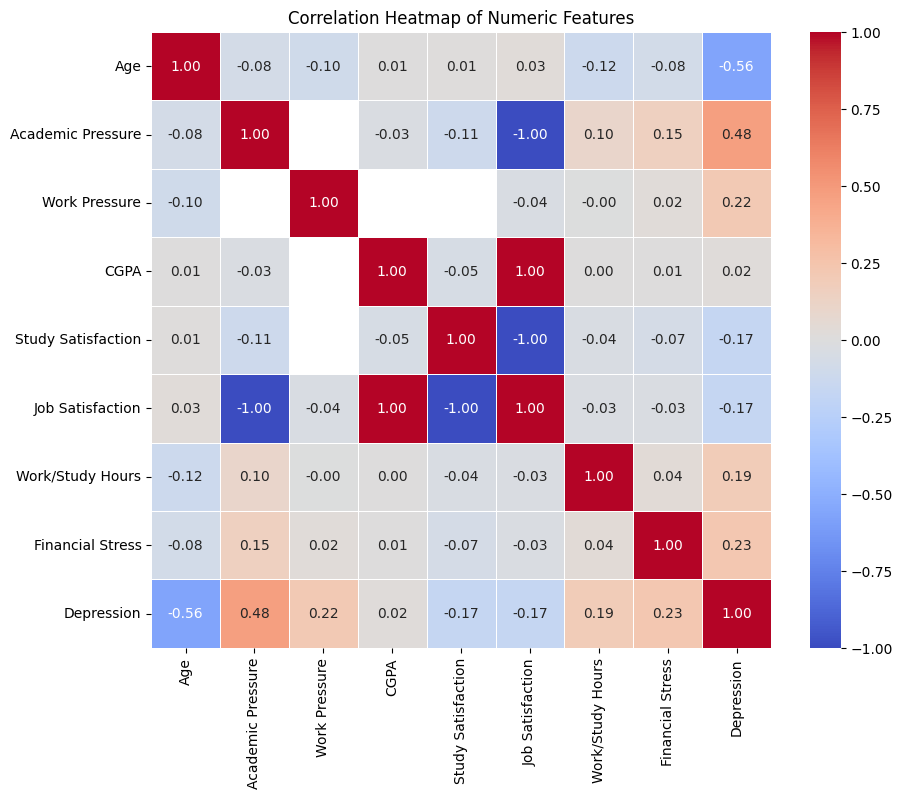

In [23]:
# Heatmap of correlations between numeric features, nửa trên đã được hiển thị ở phần trước, phần này sẽ hiển thị heatmap với chú thích rõ ràng hơn và loại bỏ cột 'id' nếu có trong dữ liệu
numeric_cols = df_train.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['id'], errors='ignore')  # Loại bỏ cột id nếu có
correlation_matrix = df_train[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')    


#### **Nhận xét:**

1. Hai biến tương quan rõ rệt nhất với biến mục tiêu là `Age` (-0.56) và `Academic Pressure` (0.48) cho thấy càng lớn tuổi thì xu hướng Trầm cảm giảm xuống. Ngược lại Academic Pressure có tương quan dương khá rõ khi áp lực học tập càng tăng thì nguy cơ Trầm cảm cũng tăng
2. Các đặc trưng còn lại đều ở mức yếu và vừa so với Depression. Chỉ có biến `CGPA` gần như không có tương quan với biến mục tiêu khi có giá trị tương quan là 0.02.
3. Có một vài ô có giá trị -1 và 1 liên quan giữa các đặc trưng `Job Satisfaction`, `Study Satisfaction`, `CGPA`, `Academic Pressure` là do mẫu dữ liệu bị missing chứ chúng không phải tương quan thật sự.

**Cross-tabulation**

In [24]:
# Thống kê mô tả cho các cột số theo từng nhóm Depression
stats_df = df_train.groupby('Depression')[numeric_cols].agg(['mean', 'median'])
display(stats_df)

Age        Academic Pressure        Work Pressure         \
                 mean median              mean median          mean median   
Depression                                                                   
0           43.683948   45.0          2.362771    2.0      2.908121    3.0   
1           25.549145   24.0          3.693928    4.0      4.019519    4.0   

                CGPA        Study Satisfaction        Job Satisfaction         \
                mean median               mean median             mean median   
Depression                                                                      
0           7.620812   7.64           3.216553    3.0         3.045644    3.0   
1           7.685407   7.85           2.752663    3.0         2.174813    2.0   

           Work/Study Hours        Financial Stress        Depression         
                       mean median             mean median       mean median  
Depression                                                                    
0                  5.904476    6.0         2.837610    3.0        0.0    0.0  
1                  7.820706    9.0         3.670656    4.0        1.0    1.0

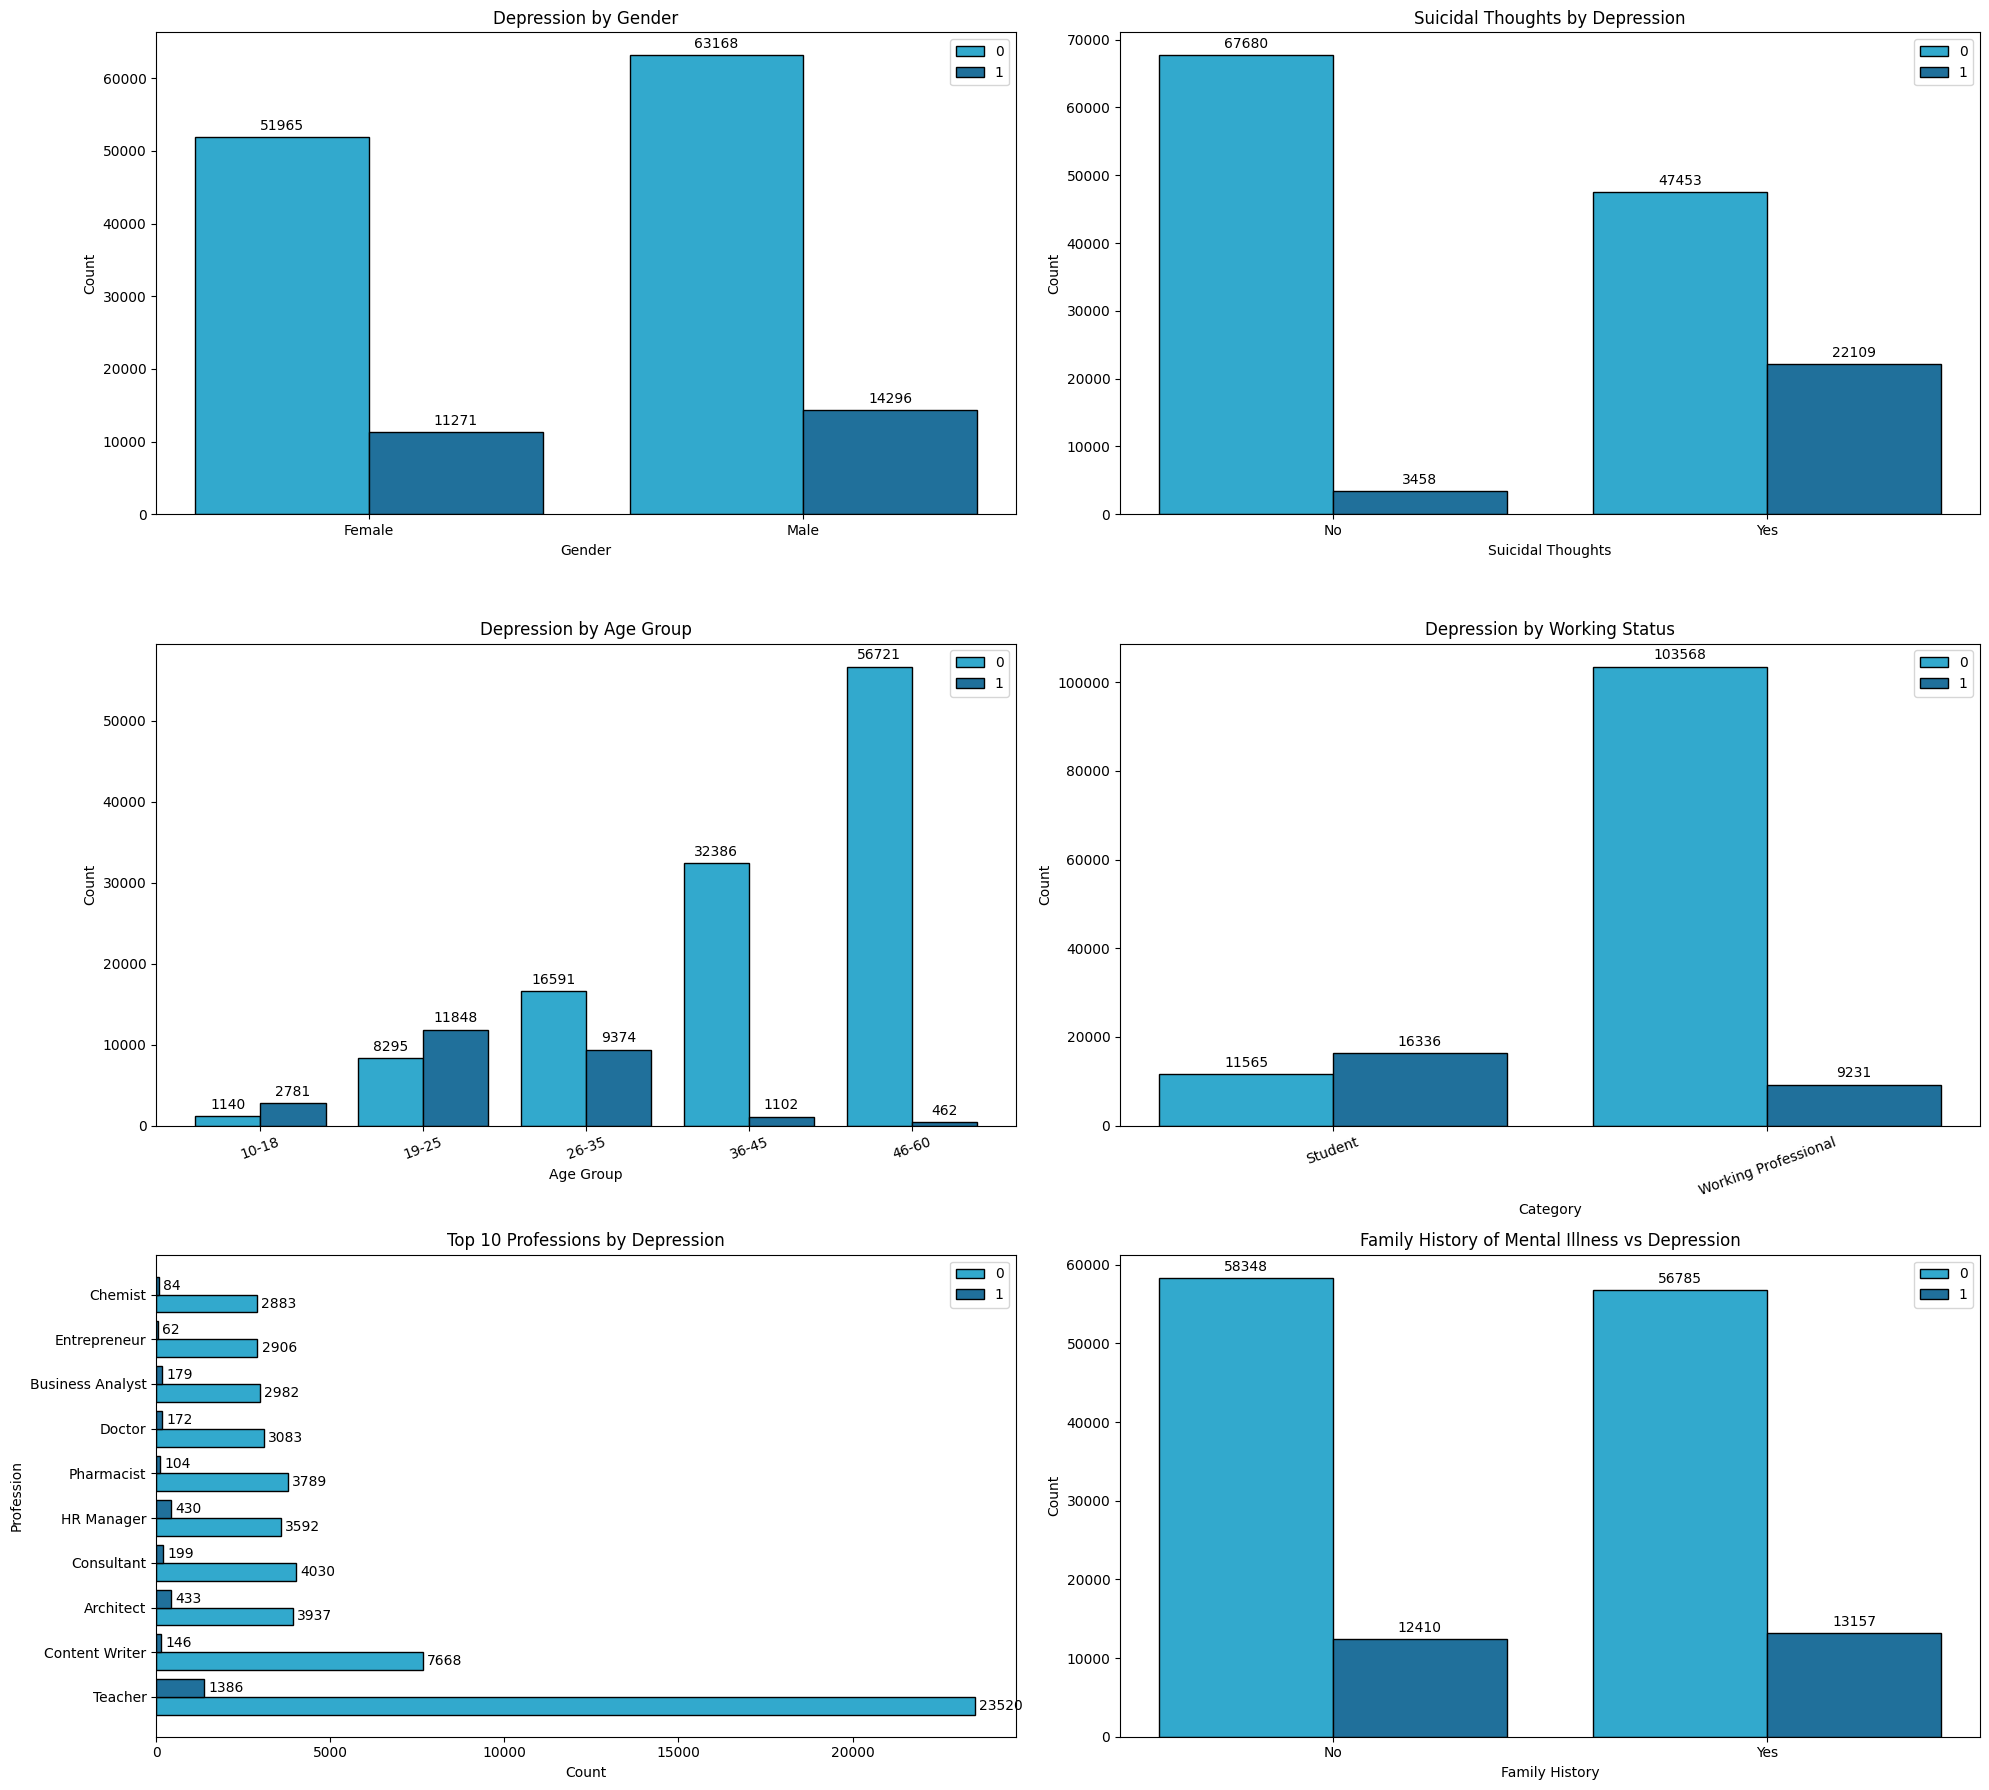

In [27]:
palette = [ '#32A9CD', '#20709b', '#047994', '#298BA8', '#80d0f0', '#a0e0f5']
hue_colors = palette[:2]

# Clean top professions
train_clean = df_train[~df_train['Profession'].isin(['Unknown']) & df_train['Profession'].notnull()]
top10_professions = train_clean['Profession'].value_counts().head(10).index.tolist()

# Create Age Group
bins = [10, 18, 25, 35, 45, 60, 100]
labels = ['10-18', '19-25', '26-35', '36-45', '46-60', '60+']
df_train['Age Group'] = pd.cut(df_train['Age'], bins=bins, labels=labels)

def plot_grouped_bars(ax, table, title, xlabel, ylabel, rotate=0, horizontal=False):
    categories = table.index.tolist()
    hue_levels = table.columns.tolist()
    if horizontal:
        y_positions = np.arange(len(categories))
        height = 0.8 / max(len(hue_levels), 1)
        offsets = (np.arange(len(hue_levels)) - (len(hue_levels) - 1) / 2) * height
        for idx, hue_value in enumerate(hue_levels):
            bars = ax.barh(
                y_positions + offsets[idx],
                table[hue_value].values,
                height=height,
                color=hue_colors[idx % len(hue_colors)],
                edgecolor='black',
                label=str(hue_value)
            )
            ax.bar_label(bars, fmt='%d', padding=3)
        ax.set_yticks(y_positions)
        ax.set_yticklabels(categories)
    else:
        x_positions = np.arange(len(categories))
        width = 0.8 / max(len(hue_levels), 1)
        offsets = (np.arange(len(hue_levels)) - (len(hue_levels) - 1) / 2) * width
        for idx, hue_value in enumerate(hue_levels):
            bars = ax.bar(
                x_positions + offsets[idx],
                table[hue_value].values,
                width=width,
                color=hue_colors[idx % len(hue_colors)],
                edgecolor='black',
                label=str(hue_value)
            )
            ax.bar_label(bars, fmt='%d', padding=3)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(categories, rotation=rotate)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(title='Depression' if 'Depression' in str(table.columns.tolist()) else None)

# Build crosstabs
gender_depression = pd.crosstab(df_train['Gender'], df_train['Depression']).reindex(columns=[0, 1], fill_value=0)
depression_suicidal = pd.crosstab(df_train['Have you ever had suicidal thoughts ?'], df_train['Depression']).reindex(columns=[0, 1], fill_value=0)
age_group_depression = pd.crosstab(df_train['Age Group'], df_train['Depression']).reindex(columns=[0, 1], fill_value=0)
working_status_depression = pd.crosstab(df_train['Working Professional or Student'], df_train['Depression']).reindex(columns=[0, 1], fill_value=0)
profession_depression = pd.crosstab(train_clean['Profession'], train_clean['Depression']).reindex(index=top10_professions, columns=[0, 1], fill_value=0)
family_history_depression = pd.crosstab(df_train['Family History of Mental Illness'], df_train['Depression']).reindex(columns=[0, 1], fill_value=0)

# Setup subplots (3 rows × 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

plot_grouped_bars(axes[0,0], gender_depression, 'Depression by Gender', 'Gender', 'Count')
plot_grouped_bars(axes[0,1], depression_suicidal, 'Suicidal Thoughts by Depression', 'Suicidal Thoughts', 'Count')
plot_grouped_bars(axes[1,0], age_group_depression, 'Depression by Age Group', 'Age Group', 'Count', rotate=20)
plot_grouped_bars(axes[1,1], working_status_depression, 'Depression by Working Status', 'Category', 'Count', rotate=20)
plot_grouped_bars(axes[2,0], profession_depression, 'Top 10 Professions by Depression', 'Count', 'Profession', horizontal=True)
plot_grouped_bars(axes[2,1], family_history_depression, 'Family History of Mental Illness vs Depression', 'Family History', 'Count')

plt.tight_layout()
plt.show()

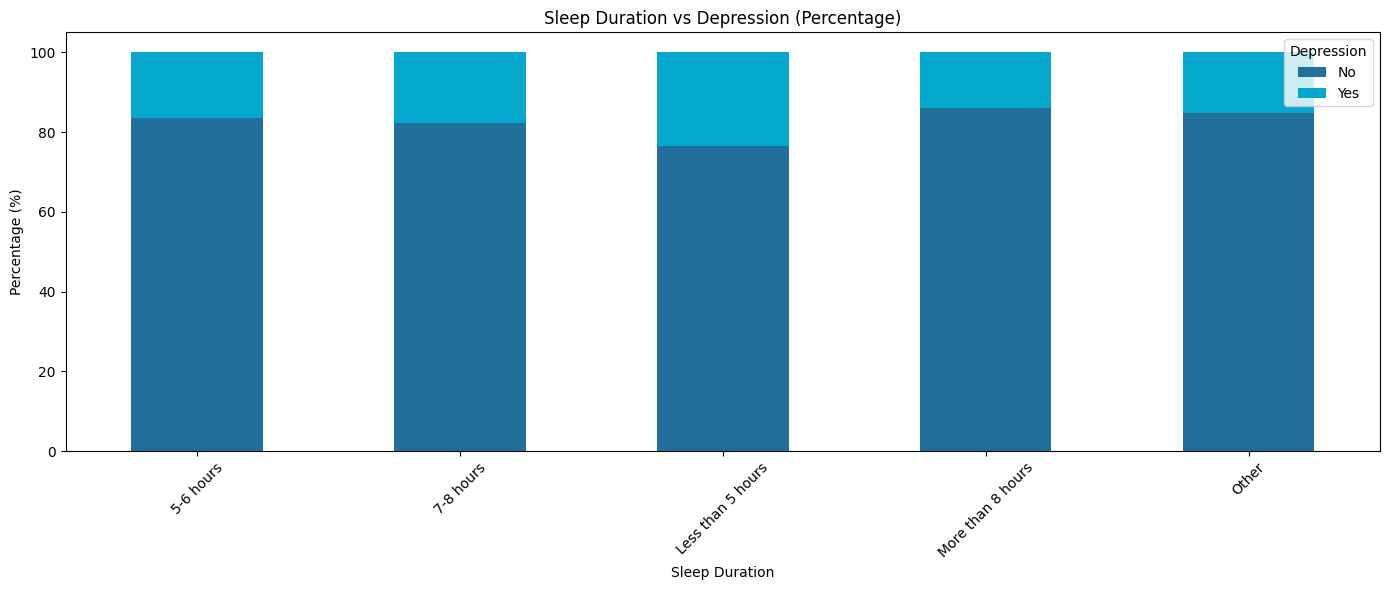

In [26]:
# Cross-tabulation of Sleep Duration and Depression
sleep_depression_ct = pd.crosstab(
    df_train['Sleep Duration'],
    df_train['Depression']
)
margins_name='Total'  

# Convert counts to percentage
sleep_depression_pct = sleep_depression_ct.div(
    sleep_depression_ct.sum(axis=1),
    axis=0
) * 100
colors = ['#20709b', '#05A7CC']
# Plot percentage stacked bar chart
sleep_depression_pct.plot(
    kind='bar',
    stacked=True,
    color = colors,
    figsize=(14,6)
)

plt.title('Sleep Duration vs Depression (Percentage)')
plt.xlabel('Sleep Duration')
plt.ylabel('Percentage (%)')
plt.legend(title='Depression', labels=['No', 'Yes'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Nhận xét:**
1. Mối quan hệ giữa `Depression` và `Gender`: Nam giới có tỷ lệ mắc trầm cảm cao hơn một chút so với nữ giới. Không thể giải thích Trầm cảm hay không chỉ dựa vào giới tính do không có dấu hiệu khác biệt rõ rệt giữa 2 giới.
2. Mối quan hệ giữa `Depression` và `Suicidal thoughts`: Những người tham gia báo cáo có suy nghĩ tự tử có nguy cơ bị trầm cảm cao hơn nhiều.
3. Mối quan hệ giữa `Depression` và `Age`: Những người tham gia trẻ tuổi (19-25) có số ca trầm cảm cao nhất. Các nhóm tuổi lớn hơn (36 trở lên) có số ca trầm cảm ít hơn.
4. Mối quan hệ giữa `Depression` và `Working Status`: Sinh viên có tỷ lệ trầm cảm cao hơn so với những người đang đi làm. Điều này cho thấy áp lực học tập có thể làm tăng nguy cơ trầm cảm.
5. Mối quan hệ giữa `Depression` và `Professions`: Một số nghề nghiệp có tỷ lệ trầm cảm cao hơn, ví dụ: giáo viên, kiến trúc sư, quản trị nhân sự. Việc xác định các nghề nghiệp có nguy cơ cao giúp nhắm mục tiêu các biện pháp can thiệp phòng ngừa.
6. Mối quan hệ giữa `Depression` và `Family History`: Những người tham gia có tiền sử gia đình mắc bệnh tâm thần có nguy cơ bị trầm cảm cao hơn đáng kể.
7. Mối quan hệ giữa `Depression` và `Sleep Duration`: Những người tham gia ngủ ít hơn 5 tiếng một ngày có nguy cơ trầm cảm cao hơn so với các nhóm ngủ còn lại.